🌟 **Daily Challenge: Interactive Data Visualization with Matplotlib and Seaborn**

I explore sales over time, country coverage, top-selling products, and the relationship between discounts and profit. I use Matplotlib with interactive controls and Seaborn for statistical comparisons.

Keep `US Superstore data (1).xls` and `ne_110m_admin_0_countries.geojson` beside this notebook. Run the cells from top to bottom in Jupyter Notebook or JupyterLab. Required packages: pandas, numpy, matplotlib, seaborn, ipywidgets and xlrd. If needed, run `%pip install pandas numpy matplotlib seaborn ipywidgets xlrd` in a separate cell.

Dropdowns require a running Python kernel and widget support. Saved static charts are included because GitHub does not run notebook widgets.

Assignment: [Interactive Data Visualization](https://octopus.developers.institute/courses/collection/229/course/812/section/1712/chapter/3347). Sales and profit are in US dollars.

In [1]:
import json
import textwrap
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import ipywidgets as widgets

from matplotlib.patches import Polygon, Patch
from matplotlib.collections import PatchCollection
from matplotlib.colors import Normalize
from matplotlib.ticker import PercentFormatter, StrMethodFormatter
from IPython.display import display

pd.options.display.float_format = "{:,.2f}".format

**🌟 1. Data Preparation**

I load the Orders sheet and inspect its structure. Each row is an order line, so repeated order IDs are expected. Postal codes are identifiers, not quantities.

In [2]:
df = pd.read_excel("US Superstore data (1).xls", sheet_name="Orders", engine="xlrd")
df.columns = df.columns.str.strip()
print("Original shape:", df.shape)
display(df.head())
df.info()
print("Missing values:")
print(df.isna().sum())
print("Exact duplicates:", df.duplicated().sum())

Original shape: (9994, 21)


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.96,2,0.00,41.91
1,2,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.94,3,0.00,219.58
2,3,CA-2016-138688,2016-06-12,2016-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.62,2,0.00,6.87
3,4,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.58,5,0.45,-383.03
4,5,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.37,2,0.20,2.52


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Row ID         9994 non-null   int64         
 1   Order ID       9994 non-null   object        
 2   Order Date     9994 non-null   datetime64[ns]
 3   Ship Date      9994 non-null   datetime64[ns]
 4   Ship Mode      9994 non-null   object        
 5   Customer ID    9994 non-null   object        
 6   Customer Name  9994 non-null   object        
 7   Segment        9994 non-null   object        
 8   Country        9994 non-null   object        
 9   City           9994 non-null   object        
 10  State          9994 non-null   object        
 11  Postal Code    9994 non-null   int64         
 12  Region         9994 non-null   object        
 13  Product ID     9994 non-null   object        
 14  Category       9994 non-null   object        
 15  Sub-Category   9994 n

In [3]:
for column in df.select_dtypes(include=["object", "string"]).columns:
    df[column] = df[column].str.strip().replace("", pd.NA)
rows_before = len(df)
df = df.drop_duplicates().copy()
print("Exact duplicates removed:", rows_before - len(df))
for column in ["Order Date", "Ship Date"]:
    df[column] = pd.to_datetime(df[column], errors="coerce")
for column in ["Sales", "Profit", "Quantity", "Discount"]:
    df[column] = pd.to_numeric(df[column], errors="coerce").replace([np.inf, -np.inf], np.nan)
df["Postal Code"] = df["Postal Code"].astype("Int64").astype("string").str.zfill(5)
required = ["Row ID", "Order ID", "Order Date", "Sales", "Profit", "Country", "Category", "Product ID", "Product Name", "Discount"]
missing_required = df[required].isna().any(axis=1)
print("Rows excluded for missing essential fields:", missing_required.sum())
df = df.loc[~missing_required].copy()
print("Rows retained:", len(df))
print("Ship dates before order dates:", (df["Ship Date"] < df["Order Date"]).sum())
print("Date range:", df["Order Date"].min().date(), "to", df["Order Date"].max().date())
assert df["Row ID"].is_unique
assert (df["Sales"] > 0).all()
assert df["Discount"].between(0, 1).all()
total_sales = df["Sales"].sum()
total_profit = df["Profit"].sum()
print(f"Total sales: ${total_sales:,.2f}")
print(f"Total profit: ${total_profit:,.2f}")

Exact duplicates removed: 0
Rows excluded for missing essential fields: 0
Rows retained: 9994
Ship dates before order dates: 0
Date range: 2014-01-03 to 2017-12-30
Total sales: $2,297,200.86
Total profit: $286,397.02


In [4]:
df["Order Year"] = df["Order Date"].dt.year
print("Countries:", df["Country"].unique().tolist())
print("Missing categories:", df["Category"].isna().sum())
print("Missing product IDs:", df["Product ID"].isna().sum())
assert df[["Country", "Category", "Product ID", "Product Name", "Discount"]].notna().all().all()

annual_sales = df.groupby("Order Year")["Sales"].sum()
annual_summary = annual_sales.to_frame()
annual_summary["Sales Growth (%)"] = annual_sales.pct_change() * 100
display(annual_summary)

Countries: ['United States']
Missing categories: 0
Missing product IDs: 0


,Sales,Sales Growth (%)
Order Year,,
2014,"484,247.50",NaN
2015,"470,532.51",-2.83
2016,"609,205.60",29.47
2017,"733,215.26",20.36


All 9,994 rows are retained. There are no missing values or exact duplicates, and order dates run from January 3, 2014 to December 30, 2017. I preserve negative profits and large transactions because they are relevant to the analysis. Total sales are $2,297,200.86 and total profit is $286,397.02.

I do not fill missing business measures with invented values. The cleaning code reports and excludes rows missing essential fields if the source changes.

**🌟 2. Interactive Sales Trends with Matplotlib**

I sum sales by year and use a category dropdown to compare trends. The chart below is the saved all-category view. The next cell adds the interactive control.

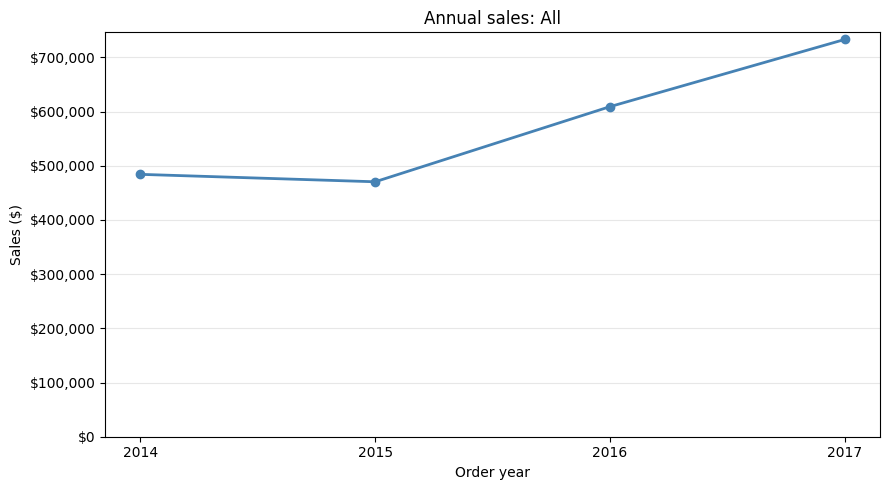

In [5]:
def plot_sales_trend(category="All"):
    selected = df if category == "All" else df.loc[df["Category"] == category]
    yearly_sales = selected.groupby("Order Year")["Sales"].sum()
    fig, ax = plt.subplots(figsize=(9, 5))
    ax.plot(yearly_sales.index, yearly_sales.values, marker="o", color="steelblue", linewidth=2)
    ax.set(title=f"Annual sales: {category}", xlabel="Order year", ylabel="Sales ($)")
    ax.set_xticks(sorted(df["Order Year"].unique()))
    ax.set_ylim(bottom=0)
    ax.yaxis.set_major_formatter(StrMethodFormatter("${x:,.0f}"))
    ax.grid(axis="y", alpha=0.3)
    plt.tight_layout()
    plt.show()

plot_sales_trend()

In [6]:
category_options = ["All"] + sorted(df["Category"].unique().tolist())
trend_dropdown = widgets.Dropdown(options=category_options, value="All", description="Category:")
trend_widget = widgets.interactive(plot_sales_trend, category=trend_dropdown)
display(trend_widget)

interactive(children=(Dropdown(description='Category:', options=('All', 'Furniture', 'Office Supplies', 'Techn…

Sales fall from $484,247.50 in 2014 to $470,532.51 in 2015, then rise to $609,205.60 in 2016 and $733,215.26 in 2017. Growth in 2017 is 20.36% compared with 2016. The category filter helps check whether each category follows the overall pattern. Annual totals do not reveal monthly seasonality.

**🌟 3. Interactive Country Sales Map with Matplotlib**

The dataset contains only the United States. I show its sales on a world map, with year and category controls. Gray countries mean **no observations in this dataset**, not zero sales. The map describes country coverage but cannot compare international markets.

Boundaries: [Natural Earth, 1:110m countries](https://www.naturalearthdata.com/downloads/110m-cultural-vectors/110m-admin-0-countries/), distributed as [GeoJSON](https://github.com/nvkelso/natural-earth-vector/blob/master/geojson/ne_110m_admin_0_countries.geojson). Natural Earth boundaries are public domain. The bundled file lets this notebook run without downloading map data.

,Sales
Country,
United States,"2,297,200.86"


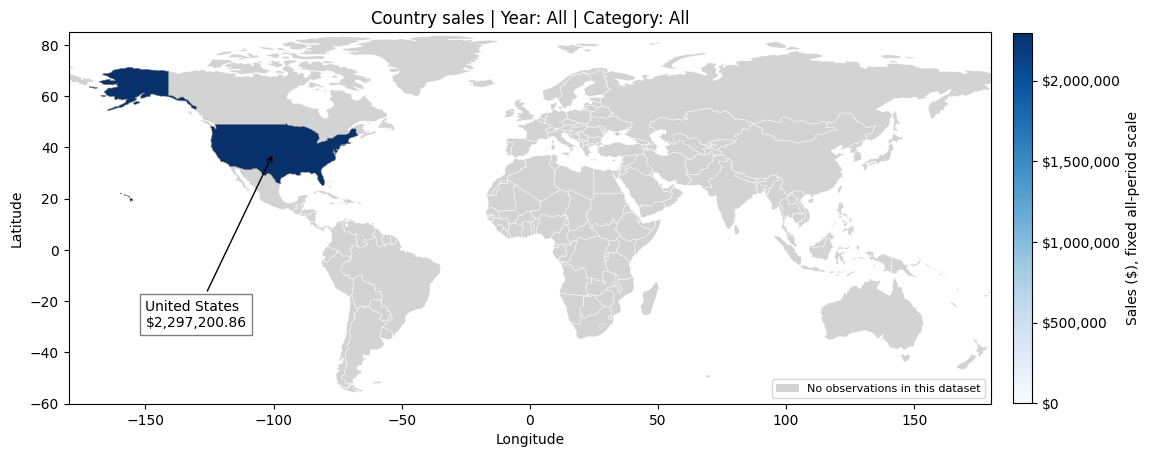

In [7]:
with open("ne_110m_admin_0_countries.geojson", encoding="utf-8") as file:
    world = json.load(file)

country_sales = df.groupby("Country")["Sales"].sum()
display(country_sales.to_frame())
assert set(df["Country"]) == {"United States"}, "Update the country-name mapping for new countries."

# Build polygon shapes from the map, keeping the US separate for coloring.
world_polygons = []
us_polygons = []
for feature in world["features"]:
    geometry = feature["geometry"]
    polygons = [geometry["coordinates"]] if geometry["type"] == "Polygon" else geometry["coordinates"]
    for polygon in polygons:
        shape = Polygon(polygon[0], closed=True)
        if feature["properties"]["ADMIN"] == "United States of America":
            us_polygons.append(shape)
        else:
            world_polygons.append(shape)

assert us_polygons, "US boundary was not found."
# A fixed scale makes colors comparable when filters change.
sales_scale = Normalize(vmin=0, vmax=country_sales.max())

def plot_country_sales(year="All", category="All"):
    selected = df
    if year != "All":
        selected = selected.loc[selected["Order Year"] == year]
    if category != "All":
        selected = selected.loc[selected["Category"] == category]
    us_sales = selected["Sales"].sum()

    fig, ax = plt.subplots(figsize=(12, 6))
    ax.add_collection(PatchCollection(world_polygons, facecolor="lightgray", edgecolor="white", linewidth=0.3))
    usa = PatchCollection(us_polygons, cmap="Blues", norm=sales_scale, edgecolor="gray", linewidth=0.4)
    usa.set_array(np.full(len(us_polygons), us_sales))
    ax.add_collection(usa)
    colorbar = fig.colorbar(usa, ax=ax, shrink=0.65, pad=0.02)
    colorbar.set_label("Sales ($), fixed all-period scale")
    colorbar.ax.yaxis.set_major_formatter(StrMethodFormatter("${x:,.0f}"))
    ax.annotate(f"United States\n${us_sales:,.2f}", xy=(-100, 38), xytext=(-150, -30),
                arrowprops={"arrowstyle": "->", "color": "black"},
                bbox={"facecolor": "white", "edgecolor": "gray"})
    ax.set(xlim=(-180, 180), ylim=(-60, 85), xlabel="Longitude", ylabel="Latitude",
           title=f"Country sales | Year: {year} | Category: {category}")
    ax.set_aspect("equal")
    ax.legend(handles=[Patch(facecolor="lightgray", label="No observations in this dataset")],
              loc="lower right", fontsize=8)
    plt.tight_layout()
    plt.show()

plot_country_sales()

In [8]:
year_options = ["All"] + sorted(df["Order Year"].unique().tolist())
map_year = widgets.Dropdown(options=year_options, value="All", description="Year:")
map_category = widgets.Dropdown(options=category_options, value="All", description="Category:")
map_widget = widgets.interactive(plot_country_sales, year=map_year, category=map_category)
display(map_widget)

interactive(children=(Dropdown(description='Year:', options=('All', 2014, 2015, 2016, 2017), value='All'), Dro…

The United States accounts for 100% of recorded sales, totaling $2,297,200.86. Changing the controls updates the sales value and map color. I keep the color scale fixed so a darker shade always represents the same sales amount.

For regional marketing decisions, a state-level comparison would be more informative. The map uses longitude and latitude directly, which distorts areas and distances, so I use it only to locate the country and display sales.

**🌟 4. Top 10 Products by Sales with Seaborn**

I aggregate sales by Product ID before ranking products. Names are labels, and different IDs remain separate even if their names match. The table includes IDs and full product names.

,Product ID,Product_Name,Sales,Profit
0,TEC-CO-10004722,Canon imageCLASS 2200 Advanced Copier,"61,599.82","25,199.93"
1,OFF-BI-10003527,Fellowes PB500 Electric Punch Plastic Comb Bin...,"27,453.38","7,753.04"
2,TEC-MA-10002412,Cisco TelePresence System EX90 Videoconferenci...,"22,638.48","-1,811.08"
3,FUR-CH-10002024,HON 5400 Series Task Chairs for Big and Tall,"21,870.58",0.00
4,OFF-BI-10001359,GBC DocuBind TL300 Electric Binding System,"19,823.48","2,233.51"
5,OFF-BI-10000545,GBC Ibimaster 500 Manual ProClick Binding System,"19,024.50",760.98
6,TEC-CO-10001449,Hewlett Packard LaserJet 3310 Copier,"18,839.69","6,983.88"
7,TEC-MA-10001127,HP Designjet T520 Inkjet Large Format Printer ...,"18,374.90","4,094.98"
8,OFF-BI-10004995,GBC DocuBind P400 Electric Binding System,"17,965.07","-1,878.17"
9,OFF-SU-10000151,High Speed Automatic Electric Letter Opener,"17,030.31",-262.00


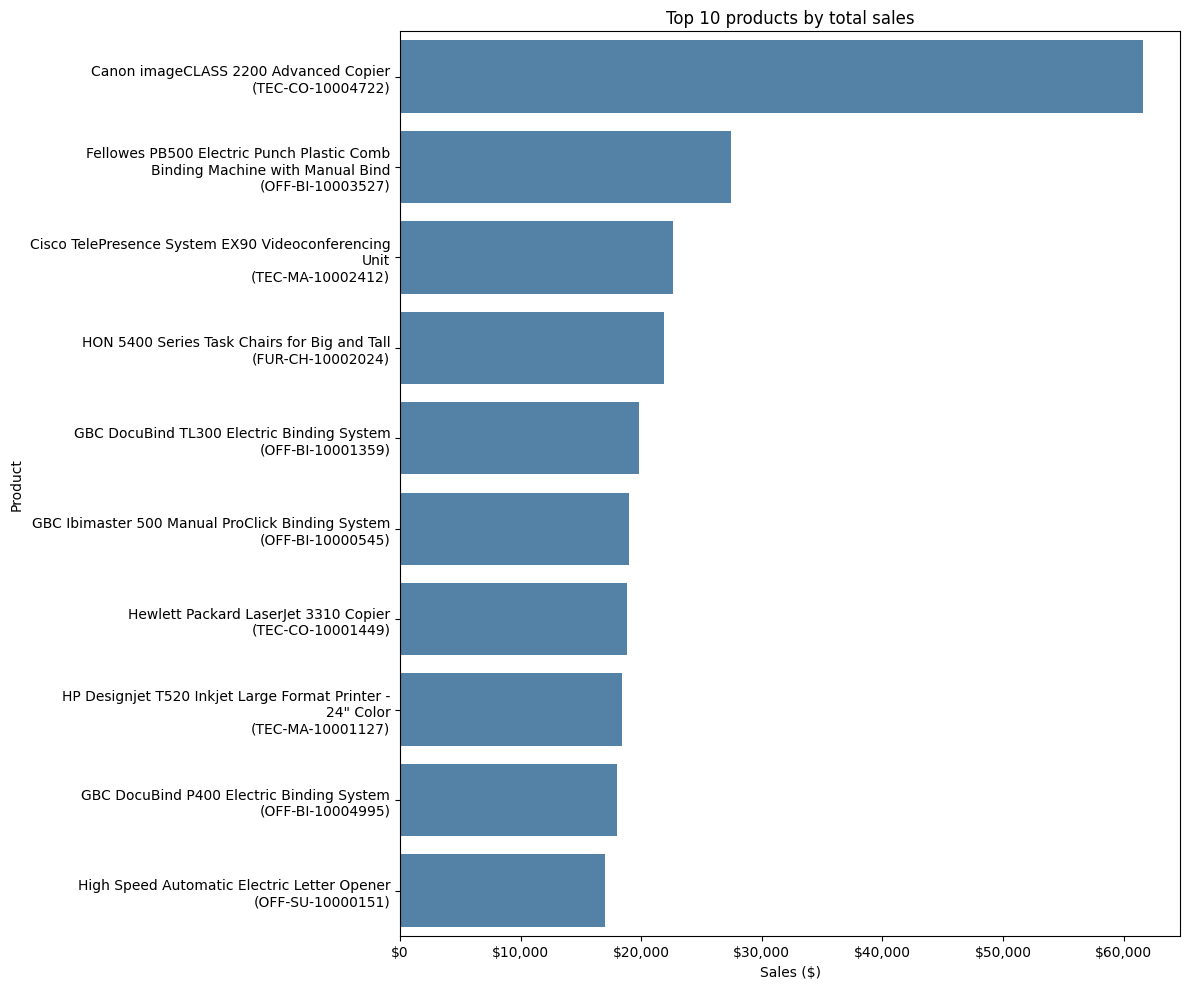

Top 10 products' share of sales: 10.65%


In [9]:
products = df.groupby("Product ID").agg(
    Product_Name=("Product Name", "first"), Sales=("Sales", "sum"), Profit=("Profit", "sum")
)
top_products = products.sort_values("Sales", ascending=False).head(10).reset_index()
display(top_products)

top_products["Chart Label"] = [textwrap.fill(name, 48) + "\n(" + product_id + ")"
    for name, product_id in zip(top_products["Product_Name"], top_products["Product ID"])]
fig, ax = plt.subplots(figsize=(12, 10))
sns.barplot(data=top_products, x="Sales", y="Chart Label", color="steelblue", errorbar=None, ax=ax)
ax.set(title="Top 10 products by total sales", xlabel="Sales ($)", ylabel="Product")
ax.xaxis.set_major_formatter(StrMethodFormatter("${x:,.0f}"))
plt.tight_layout()
plt.show()
print(f"Top 10 products' share of sales: {top_products['Sales'].sum() / total_sales:.2%}")

The Canon imageCLASS 2200 Advanced Copier leads with $61,599.82 in sales, followed by the Fellowes PB500 binding machine ($27,453.38) and Cisco TelePresence System EX90 ($22,638.48). These are sales rankings, so I include profit in the table before recommending any promotion. High revenue alone does not establish that a product is profitable.

**🌟 5. Profit and Discount with Seaborn**

Each point is an order line. I color points by product category, use transparency to reduce overlap, and retain all losses and large profits. Discount is shown as a percentage.

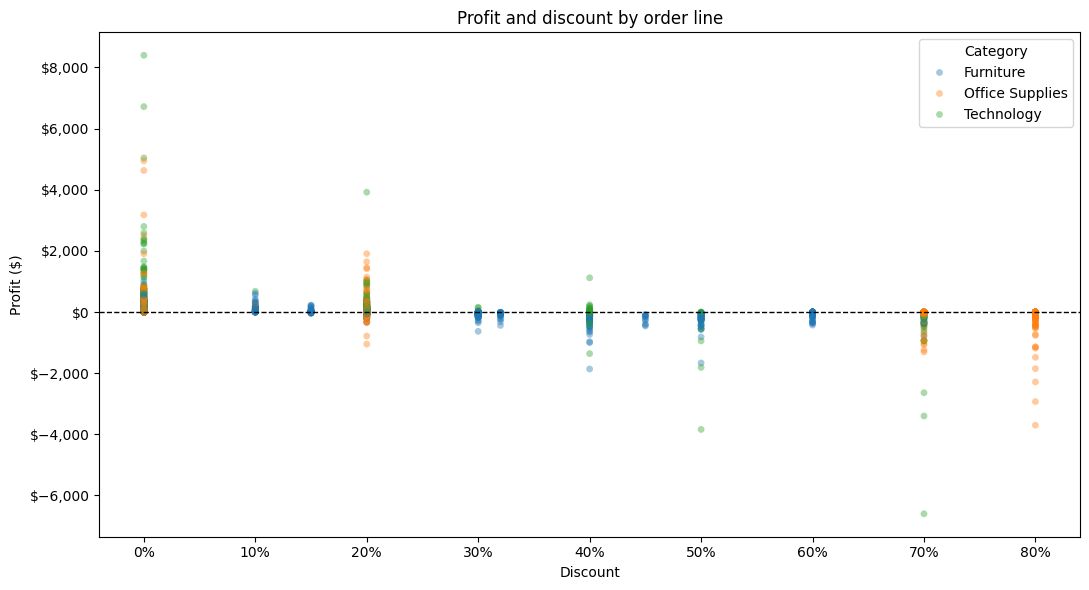

,Order_Lines,Average_Profit,Total_Profit,Loss_Rate
Discount,,,,
0.00,4798,66.90,"320,987.60",0.00
0.10,94,96.06,"9,029.18",0.04
0.15,52,27.29,"1,418.99",0.33
0.20,3657,24.70,"90,337.31",0.14
0.30,227,-45.68,"-10,369.28",0.92
0.32,27,-88.56,"-2,391.14",1.00
0.40,206,-111.93,"-23,057.05",0.87
0.45,11,-226.65,"-2,493.11",1.00
0.50,66,-310.70,"-20,506.43",1.00


Pearson correlation between discount and profit: -0.219


In [10]:
fig, ax = plt.subplots(figsize=(11, 6))
sns.scatterplot(data=df, x="Discount", y="Profit", hue="Category",
                alpha=0.4, s=24, linewidth=0, ax=ax)
ax.axhline(0, color="black", linestyle="--", linewidth=1)
ax.set(title="Profit and discount by order line", xlabel="Discount", ylabel="Profit ($)")
ax.xaxis.set_major_formatter(PercentFormatter(1))
ax.yaxis.set_major_formatter(StrMethodFormatter("${x:,.0f}"))
plt.tight_layout()
plt.show()

discount_summary = df.groupby("Discount").agg(
    Order_Lines=("Profit", "size"), Average_Profit=("Profit", "mean"),
    Total_Profit=("Profit", "sum"), Loss_Rate=("Profit", lambda values: (values < 0).mean())
)
display(discount_summary)
correlation = df["Discount"].corr(df["Profit"])
print(f"Pearson correlation between discount and profit: {correlation:.3f}")

The correlation is approximately −0.219, indicating a weak negative linear association between discount and order-line profit. Every observed discount level of 30% or more has negative average profit in this dataset. The grouped table supports this observation because overlapping points make the scatter plot difficult to read precisely.

Discounts occur at a few discrete levels, which creates vertical stacks of points. Profit is also influenced by product mix, quantity and other factors. This observational chart does not establish that discounts cause losses or identify a universally safe discount threshold.

**🌟 6. Comparative Analysis**

| Tool | Insights from these charts | Ease of use and effectiveness |
|---|---|---|
| Matplotlib | The line chart shows the 2015 sales dip and later growth. The map confirms US-only coverage and shows sales for each selected year and category. | Direct control over axes, labels, map polygons and color scales is useful. The map requires more preparation, and ipywidgets supplies the controls. |
| Seaborn | The bar chart identifies sales-leading products. The scatter plot shows discount-profit patterns and category differences. | DataFrame inputs and automatic category legends make these comparisons concise. Matplotlib still handles final labels and formatting. |

I prefer Matplotlib here for custom layouts and the map. Seaborn makes the product comparison and category-colored scatter plot quicker to express. Seaborn is built on Matplotlib, and either library can be combined with widget controls. Neither chart library alone supplies the dropdown interface used in this notebook.

The charts answer different questions: the line chart describes time, the map describes coverage, the bar chart ranks products, and the scatter plot explores an association. I use tables alongside the charts to verify exact values.

**🌟 7. Key Insights and Recommendations**

- **Sales trend:** 2017 has the highest annual sales, with 20.36% growth from 2016. Compare category trends before deciding where to expand.
- **Country coverage:** All recorded sales are in the United States. This dataset cannot support international market comparisons.
- **Products:** The Canon copier is the sales leader. Review profit and demand before promoting the top-selling products.
- **Discounts:** Higher observed discount levels are associated with losses on average. Review discount policies by product and category and test changes before treating this association as a causal result.

These findings describe the supplied 2014–2017 transactions. Campaign costs and experimental results are not available, so this analysis does not estimate marketing ROI.

In [11]:
# Reconcile the main summaries with the cleaned source data.
assert np.isclose(annual_sales.sum(), total_sales)
assert np.isclose(country_sales.sum(), total_sales)
assert np.isclose(products["Sales"].sum(), total_sales)
assert discount_summary["Order_Lines"].sum() == len(df)
print("Annual, country and product sales totals match the cleaned dataset.")

Annual, country and product sales totals match the cleaned dataset.
